In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [84]:
loan_data = pd.read_csv("loan_approval_data.csv")
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handle Missing Values

In [85]:
categorical_cols = loan_data.select_dtypes(include = ["object"]).columns
numerical_cols = loan_data.select_dtypes(include = ["float64"]).columns

In [86]:
num_imp = SimpleImputer(strategy = "mean")
loan_data[numerical_cols] = num_imp.fit_transform(loan_data[numerical_cols])

In [87]:
cat_imp = SimpleImputer(strategy = "most_frequent")
loan_data[categorical_cols] = cat_imp.fit_transform(loan_data[categorical_cols])

In [88]:
loan_data.nunique()

Applicant_ID          951
Applicant_Income      925
Coapplicant_Income    903
Employment_Status       4
Age                    40
Marital_Status          2
Dependents              5
Credit_Score          247
Existing_Loans          6
DTI_Ratio              52
Savings               927
Collateral_Value      943
Loan_Amount           937
Loan_Term               7
Loan_Purpose            5
Property_Area           3
Education_Level         2
Gender                  2
Employer_Category       5
Loan_Approved           2
dtype: int64

# EDA

Text(0.5, 1.0, 'Loan Appreoved')

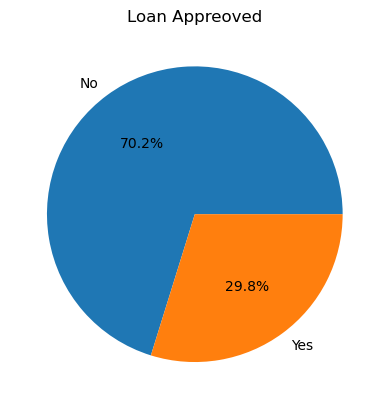

In [89]:
loan_app = loan_data["Loan_Approved"].value_counts()
plt.pie(loan_app, labels = ["No","Yes"], autopct ="%1.1f%%")
plt.title("Loan Appreoved")

<Axes: xlabel='Marital_Status', ylabel='count'>

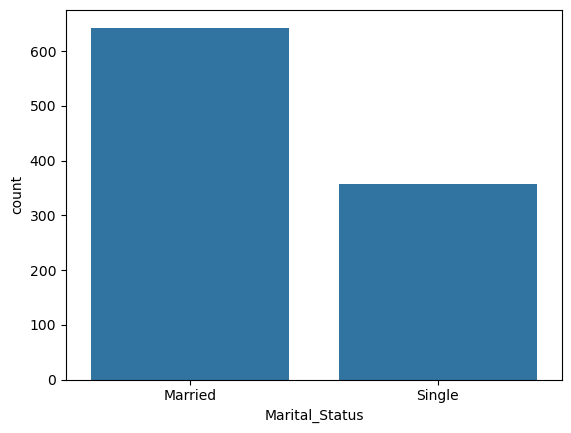

In [90]:
gen = loan_data["Marital_Status"].value_counts()
sns.barplot(gen)

Text(0.5, 1.0, 'Loan Appreoved')

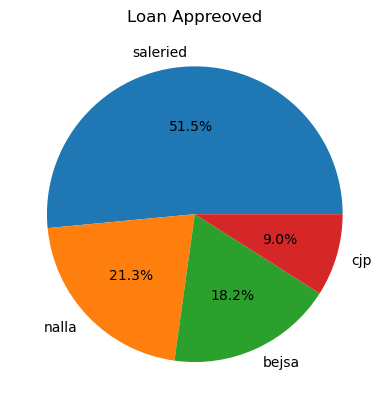

In [91]:
loan_app = loan_data["Employment_Status"].value_counts()
plt.pie(loan_app, labels = ["saleried","nalla", "bejsa", "cjp"], autopct ="%1.1f%%")
plt.title("Loan Appreoved")

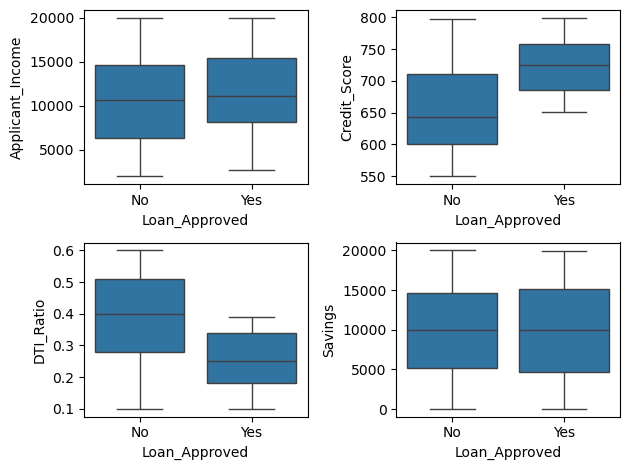

In [92]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0], data = loan_data, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = loan_data, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = loan_data, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = loan_data, x = "Loan_Approved", y = "Savings")
plt.tight_layout()

# Encoding

In [93]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [94]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
enco = LabelEncoder()
loan_data["Education_Level"] = enco.fit_transform(loan_data["Education_Level"])
loan_data["Loan_Approved"] = enco.fit_transform(loan_data["Loan_Approved"])

In [95]:
ohe = OneHotEncoder(drop = "first", sparse_output=False, handle_unknown="ignore")
cols = ["Employment_Status","Marital_Status","Loan_Purpose", "Property_Area", "Gender","Employer_Category"]
encoded = ohe.fit_transform(loan_data[cols])
encoded_data = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols),index = loan_data.index)
loan_data = pd.concat([loan_data.drop(columns = cols), encoded_data], axis = 1)

In [98]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

# Correlation Heatmap

In [99]:
num_cols = loan_data.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

In [101]:
corr_matrix["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

# Train-Test Split + Feature Scaling

In [102]:
x = loan_data.drop(columns = ["Applicant_ID","Loan_Approved"],axis =1)
y = loan_data["Loan_Approved"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [110]:
x_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

# Train & Evaluate Models

In [135]:
# logistic
log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)
y_pred_l = log_model.predict(x_test_scaled)

In [142]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print("Logistic Regression Accuracy", accuracy_score(y_test, y_pred_l))
print("Logistic Regression Precision", precision_score(y_test, y_pred_l))
print("Logistic Regression recall", recall_score(y_test, y_pred_l))
print("Logistic Regression F1", f1_score(y_test, y_pred_l))
print("Logistic Regression Confusion_matrix", confusion_matrix(y_test, y_pred_l))

Logistic Regression Accuracy 0.865
Logistic Regression Precision 0.7833333333333333
Logistic Regression recall 0.7704918032786885
Logistic Regression F1 0.7768595041322314
Logistic Regression Confusion_matrix [[126  13]
 [ 14  47]]


In [137]:
# knn
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train_scaled, y_train)
y_pred_k = knn_model.predict(x_test_scaled)

In [144]:
print("KNN Regression Accuracy", accuracy_score(y_test, y_pred_k))
print("KNN Regression Precision", precision_score(y_test, y_pred_k))
print("KNN Regression recall", recall_score(y_test, y_pred_k))
print("KNN Regression F1", f1_score(y_test, y_pred_l))
print("KNN Regression Confusion_matrix", confusion_matrix(y_test, y_pred_l))

KNN Regression Accuracy 0.76
KNN Regression Precision 0.6274509803921569
KNN Regression recall 0.5245901639344263
KNN Regression F1 0.7768595041322314
KNN Regression Confusion_matrix [[126  13]
 [ 14  47]]


In [139]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()
naive_model.fit(x_train_scaled, y_train)
y_pred_n = naive_model.predict(x_test_scaled)

In [143]:
print("Naive bayes Regression Accuracy", accuracy_score(y_test, y_pred_n))
print("Naive bayes Regression Precision", precision_score(y_test, y_pred_n))
print("Naive bayes Regression recall", recall_score(y_test, y_pred_n))
print("Naive bayes Regression F1", f1_score(y_test, y_pred_l))
print("Naive bayes Regression Confusion_matrix", confusion_matrix(y_test, y_pred_l))

Naive bayes Regression Accuracy 0.865
Naive bayes Regression Precision 0.8035714285714286
Naive bayes Regression recall 0.7377049180327869
Naive bayes Regression F1 0.7768595041322314
Naive bayes Regression Confusion_matrix [[126  13]
 [ 14  47]]


# Feature Engineering

In [155]:
# loan_data["Applicant_Income_log"] = np.log1p(loan_data["Applicant_Income"])
loan_data["DTI_Ratio_sq"] = loan_data["DTI_Ratio"] ** 2
loan_data["Credit_Score_sq"] = loan_data["Credit_Score"] ** 2

In [156]:
x = loan_data.drop(columns = ["DTI_Ratio","Credit_Score", "Loan_Approved"])
y = loan_data["Loan_Approved"]

In [157]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [158]:
# logistic
log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)
y_pred_l = log_model.predict(x_test_scaled)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print("Logistic Regression Accuracy", accuracy_score(y_test, y_pred_l))
print("Logistic Regression Precision", precision_score(y_test, y_pred_l))
print("Logistic Regression recall", recall_score(y_test, y_pred_l))
print("Logistic Regression F1", f1_score(y_test, y_pred_l))
print("Logistic Regression Confusion_matrix", confusion_matrix(y_test, y_pred_l))

Logistic Regression Accuracy 0.88
Logistic Regression Precision 0.7846153846153846
Logistic Regression recall 0.8360655737704918
Logistic Regression F1 0.8095238095238095
Logistic Regression Confusion_matrix [[125  14]
 [ 10  51]]


In [160]:
# knn
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train_scaled, y_train)
y_pred_k = knn_model.predict(x_test_scaled)

print("KNN Regression Accuracy", accuracy_score(y_test, y_pred_k))
print("KNN Regression Precision", precision_score(y_test, y_pred_k))
print("KNN Regression recall", recall_score(y_test, y_pred_k))
print("KNN Regression F1", f1_score(y_test, y_pred_l))
print("KNN Regression Confusion_matrix", confusion_matrix(y_test, y_pred_l))

KNN Regression Accuracy 0.765
KNN Regression Precision 0.6666666666666666
KNN Regression recall 0.45901639344262296
KNN Regression F1 0.8095238095238095
KNN Regression Confusion_matrix [[125  14]
 [ 10  51]]


In [159]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()
naive_model.fit(x_train_scaled, y_train)
y_pred_n = naive_model.predict(x_test_scaled)

print("Naive bayes Regression Accuracy", accuracy_score(y_test, y_pred_n))
print("Naive bayes Regression Precision", precision_score(y_test, y_pred_n))
print("Naive bayes Regression recall", recall_score(y_test, y_pred_n))
print("Naive bayes Regression F1", f1_score(y_test, y_pred_l))
print("Naive bayes Regression Confusion_matrix", confusion_matrix(y_test, y_pred_l))

Naive bayes Regression Accuracy 0.855
Naive bayes Regression Precision 0.8076923076923077
Naive bayes Regression recall 0.6885245901639344
Naive bayes Regression F1 0.8095238095238095
Naive bayes Regression Confusion_matrix [[125  14]
 [ 10  51]]
